## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2009,0.230901,0.315722,0.162619,-0.315722,0.205831,0.289935,0.158879,-0.289935,0.048579,0.050930,0.073114,0.050930,4.360424,-2.787257,0.786584,13.118672,159.569182,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840,0,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN
1,2009-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.664674,-0.116201,3.274236,7.838270,61.584229,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.344107,13.624337,242.986365,0,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,23291.0,94577.0,25594.0,143462.0,22117.0,93495.0,30638.0,146250.0,5066.81,NaN,NaN
2,2009-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.264925,1.897135,4.081030,8.009196,45.061856,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.0,1.0,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,6,1,2,-1.838750,13.054948,248.285067,0,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,15239.0,67953.0,17481.0,100673.0,14953.0,67677.0,22660.0,105290.0,3451.36,NaN,NaN
3,2009-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,2009,0.205035,0.367739,0.233671,-0.367739,0.187385,0.341510,0.220182,-0.341510,0.041014,0.045679,0.065527,0.045679,7.547264,0.200398,3.873831,4.983220,175.371069,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11

<AxesSubplot:>

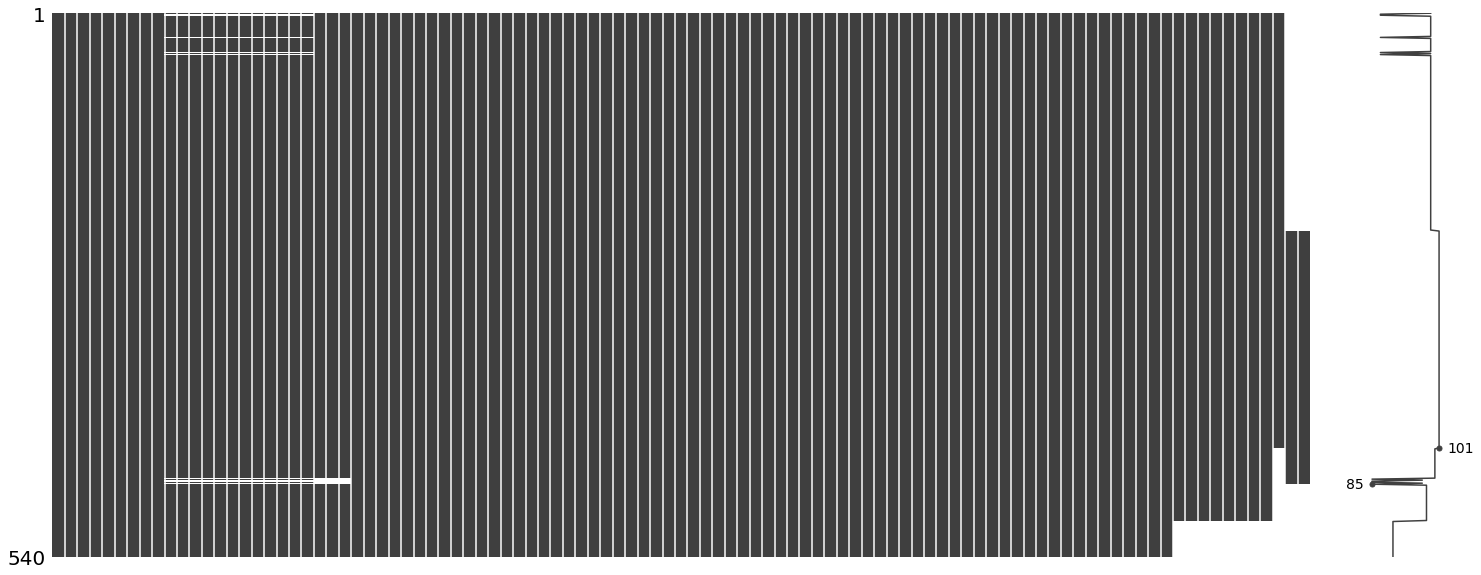

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,1.6667
1,ndmi,1.6667
2,ndwi,1.6667
3,ndbi,1.6667
4,ndvi_mean,1.6667
...,...,...
21,F_Y_GE65,6.6667
22,F_TOTAL,6.6667
23,MIO_EUR,20.0000
24,L_TOTAL,53.3333


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [7]:
data_p1 = []
data_p2 = []

for year in years[1:]:
    for region in nuts3_units:
        df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
        df_regional.reset_index(drop = True, inplace = True)

        df_period_1 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] == 1))].copy()
        df_period_2 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] <= 4))].copy()
        #df_period_2 = df_regional.loc[(df_regional['year'] == 2011) & (df_regional['month'] >= 2) & (df_regional['month'] <= 4)].copy()
        df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
        df_curr_year = df_regional.loc[(df_regional['year'] == year)].copy()

        x = df_curr_year['x'].mean()
        y = df_curr_year['y'].mean()

        ndvi_p1 = df_period_1['ndvi'].mean()
        ndwi_p1 = df_period_1['ndwi'].mean()
        ndmi_p1 = df_period_1['ndmi'].mean()
        ndbi_p1 = df_period_1['ndbi'].mean()

        ndvi_p2 = df_period_2['ndvi'].mean()
        ndwi_p2 = df_period_2['ndwi'].mean()
        ndmi_p2 = df_period_2['ndmi'].mean()
        ndbi_p2 = df_period_2['ndbi'].mean()
        #------------------------------------------------------
        lst_mean_p1 = df_period_1['lst'].mean()
        lst_day_mean_p1 = df_period_1['lst_day'].mean()
        lst_night_mean_p1 = df_period_1['lst_night'].mean()
        lst_min_p1 = df_period_1['monthly_lst_min'].min()
        lst_max_p1 = df_period_1['monthly_lst_min'].max()

        lst_mean_p2 = df_period_2['lst'].mean()
        lst_day_mean_p2 = df_period_2['lst_day'].mean()
        lst_night_mean_p2 = df_period_2['lst_night'].mean()
        lst_min_p2 = df_period_2['monthly_lst_min'].min()
        lst_max_p2 = df_period_2['monthly_lst_min'].max()
        #-------------------------------------------------------
        prec_mean_p1 = df_period_1['rainfall'].mean()
        prec_acc_p1 = df_period_1['monthly_acc_prec'].sum()

        prec_mean_p2 = df_period_2['rainfall'].mean()
        prec_acc_p2 = df_period_2['monthly_acc_prec'].sum()
        #-------------------------------------------------------
        mosq_mean_p1 = df_period_1['mosq_pred'].mean()
        mosq_sum_p1 = df_period_1['mosq_pred'].sum()

        mosq_mean_p2 = df_period_2['mosq_pred'].mean()
        mosq_sum_p2 = df_period_2['mosq_pred'].sum()
        #--------------------------------------------------------
        bio1 = df_prev_year.iloc[0]['bio1']
        bio2 = df_prev_year.iloc[0]['bio2']
        bio3 = df_prev_year.iloc[0]['bio3']
        bio4 = df_prev_year.iloc[0]['bio4']
        bio5 = df_prev_year.iloc[0]['bio5']
        bio6 = df_prev_year.iloc[0]['bio6']
        bio7 = df_prev_year.iloc[0]['bio7']
        bio8 = df_prev_year.iloc[0]['bio8']
        bio9 = df_prev_year.iloc[0]['bio9']
        bio10 = df_prev_year.iloc[0]['bio10']
        bio11 = df_prev_year.iloc[0]['bio11']
        bio12 = df_prev_year.iloc[0]['bio12']
        bio13 = df_prev_year.iloc[0]['bio13']
        bio14 = df_prev_year.iloc[0]['bio14']
        bio15 = df_prev_year.iloc[0]['bio15']
        bio16 = df_prev_year.iloc[0]['bio16']
        bio17 = df_prev_year.iloc[0]['bio17']
        bio18 = df_prev_year.iloc[0]['bio18']
        bio19 = df_prev_year.iloc[0]['bio19']
        #--------------------------------------------------------
        lc_prop1 = df_prev_year.iloc[0]['lc_prop1']
        lc_prop2 = df_prev_year.iloc[0]['lc_prop2']
        lc_prop3 = df_prev_year.iloc[0]['lc_prop3']
        lc_type1 = df_prev_year.iloc[0]['lc_type1']
        lc_type2 = df_prev_year.iloc[0]['lc_type2']
        lc_type3 = df_prev_year.iloc[0]['lc_type3']
        lc_type4 = df_prev_year.iloc[0]['lc_type4']
        lc_type5 = df_prev_year.iloc[0]['lc_type5']
        #--------------------------------------------------------
        distance_to_coast = df_prev_year.iloc[0]['distance_to_coast']
        distance_to_river = df_prev_year.iloc[0]['distance_to_river']
        slope_mean_1km = df_prev_year.iloc[0]['slope_mean_1km']
        aspect_mean_200m = df_prev_year.iloc[0]['aspect_mean_200m']
        elevation_mean_1km = df_prev_year.iloc[0]['elevation_mean_1km']
        hillshade_mean_1km = df_prev_year.iloc[0]['hillshade_mean_1km']
        fs_area_1km = df_prev_year.iloc[0]['fs_area_1km']
        flow_accu_200m = df_prev_year.iloc[0]['flow_accu_200m']

        distance_to_coast_std = df_prev_year.iloc[0]['distance_to_coast_std']
        distance_to_river_std = df_prev_year.iloc[0]['distance_to_river_std']
        slope_mean_1km_std = df_prev_year.iloc[0]['slope_mean_1km_std']
        aspect_mean_200m_std = df_prev_year.iloc[0]['aspect_mean_200m_std']
        elevation_mean_1km_std = df_prev_year.iloc[0]['elevation_mean_1km_std']
        hillshade_mean_1km_std = df_prev_year.iloc[0]['hillshade_mean_1km_std']
        fs_area_1km_std = df_prev_year.iloc[0]['fs_area_1km_std']
        flow_accu_200m_std = df_prev_year.iloc[0]['flow_accu_200m_std']
        #--------------------------------------------------------
        males_lt15 = df_prev_year.iloc[0]['M_Y_LT15']
        males_15t64 = df_prev_year.iloc[0]['M_Y15-64']
        males_gt65 = df_prev_year.iloc[0]['M_Y_GE65']
        males_total = df_prev_year.iloc[0]['M_TOTAL']

        females_lt15 = df_prev_year.iloc[0]['F_Y_LT15']
        females_15t64 = df_prev_year.iloc[0]['F_Y15-64']
        females_gt65 = df_prev_year.iloc[0]['F_Y_GE65']
        females_total = df_prev_year.iloc[0]['F_TOTAL']

        mio_eur = df_prev_year.iloc[0]['MIO_EUR']
        l_total = df_prev_year.iloc[0]['L_TOTAL']
        unl_total = df_prev_year.iloc[0]['UNL_TOTAL']
        #--------------------------------------------------------
        cases_total = df_curr_year['cases'].sum()
        cases_arr = df_curr_year.loc[(df_curr_year['month'] >= 5) & (df_curr_year['month'] <= 10)]['cases'].to_list()

        data_p1.append({'NUTS3_ID': region, 
                     'year': year, 
                     'x' : x,
                     'y': y,
                     'ndvi_p1': ndvi_p1,
                     'ndwi_p1': ndwi_p1,
                     'ndmi_p1': ndmi_p1,
                     'ndbi_p1': ndbi_p1,
                     'lst_mean_p1': lst_mean_p1,
                     'lst_day_mean_p1': lst_day_mean_p1,
                     'lst_night_mean_p1': lst_night_mean_p1,
                     'lst_min_p1': lst_min_p1,
                     'lst_max_p1': lst_max_p1,
                     'prec_mean_p1': prec_mean_p1,
                     'prec_acc_p1': prec_acc_p1,
                     'mosq_mean_p1': mosq_mean_p1,
                     'mosq_sum_p1': mosq_sum_p1,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })

        data_p2.append({'NUTS3_ID': region, 
                     'year': year,
                     'x' : x,
                     'y': y, 
                     'ndvi_p1': ndvi_p2,
                     'ndwi_p1': ndwi_p2,
                     'ndmi_p1': ndmi_p2,
                     'ndbi_p1': ndbi_p2,
                     'lst_mean_p1': lst_mean_p2,
                     'lst_day_mean_p1': lst_day_mean_p2,
                     'lst_night_mean_p1': lst_night_mean_p2,
                     'lst_min_p1': lst_min_p2,
                     'lst_max_p1': lst_max_p2,
                     'prec_mean_p1': prec_mean_p2,
                     'prec_acc_p1': prec_acc_p2,
                     'mosq_mean_p1': mosq_mean_p2,
                     'mosq_sum_p1': mosq_sum_p2,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })
        
p1_df = pd.DataFrame(data_p1)       
p2_df = pd.DataFrame(data_p2) 

In [8]:
p1_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL611,2010,21.720538,39.507246,0.352446,-0.138874,0.162237,-0.162237,6.956137,10.174854,3.737420,-1.011887,4.419748,8.420724,774.086872,435.672956,1307.018868,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
1,EL612,2010,22.407574,39.702044,0.234109,-0.199596,-0.001841,0.001841,8.611008,13.012714,4.209301,-0.746272,4.494659,5.342229,492.905788,466.477897,1399.433692,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,23291.0,94577.0,25594.0,143462.0,22117.0,93495.0,30638.0,146250.0,5066.81,NaN,NaN,9,"[0, 0, 1, 5, 3, 0]"
2,EL613,2010,22.862978,39.279998,0.312578,-0.101779,0.150343,-0.150343,9.311738,12.780707,5.842770,0.015361,5.495773,5.905381,546.165088,295.384880,886.154639,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,31,20,30,12,12,1,6,1,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,15239.0,67953.0,17481.0,100673.0,14953.0,67677.0,22660.0,105290.0,3451.36,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
3,EL611,2011,21.720538,39.507246,0.257281,0.129679,0.340779,-0.340779,6.715359,10.197633,3.233085,-4.176667,4.595031,6.175279,565.667601,368.006289,1104.018868,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,14,"[0, 0, 3, 8, 3, 0]"
4,EL612,2011,22.407574,39.702044,0.224630,0.148014,0.335510,-0.335510,7.939797,12.116715,3.762879,-4.363692,5.677025,2.561517,234.933898,551.647551,1654.942652,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,15,"[0, 0, 4, 7, 4, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [9]:
p2_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL611,2010,21.720538,39.507246,0.372201,-0.162853,0.169025,-0.169025,8.329482,12.546445,4.112518,-2.952316,4.775597,7.267220,1307.112569,380.237945,2281.427673,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
1,EL612,2010,22.407574,39.702044,0.327773,-0.170834,0.121194,-0.121194,9.919500,15.124582,4.714418,-2.924420,5.058817,4.807247,866.516939,377.661290,2265.967742,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,23291.0,94577.0,25594.0,143462.0,22117.0,93495.0,30638.0,146250.0,5066.81,NaN,NaN,9,"[0, 0, 1, 5, 3, 0]"
2,EL613,2010,22.862978,39.279998,0.370268,-0.156675,0.167245,-0.167245,10.331639,14.656511,6.006767,-1.300105,6.030619,4.673153,847.423065,282.221649,1693.329897,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,31,20,30,12,12,1,6,1,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,15239.0,67953.0,17481.0,100673.0,14953.0,67677.0,22660.0,105290.0,3451.36,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
3,EL611,2011,21.720538,39.507246,0.296756,0.026439,0.278558,-0.278558,7.949154,12.288613,3.609695,-4.176667,4.595031,5.279846,955.565744,314.046122,1884.276730,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,14,"[0, 0, 3, 8, 3, 0]"
4,EL612,2011,22.407574,39.702044,0.319995,-0.039137,0.239914,-0.239914,9.291127,14.411879,4.170376,-4.731121,5.677025,3.059526,550.679934,381.031063,2286.186380,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,15,"[0, 0, 4, 7, 4, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

<AxesSubplot:>

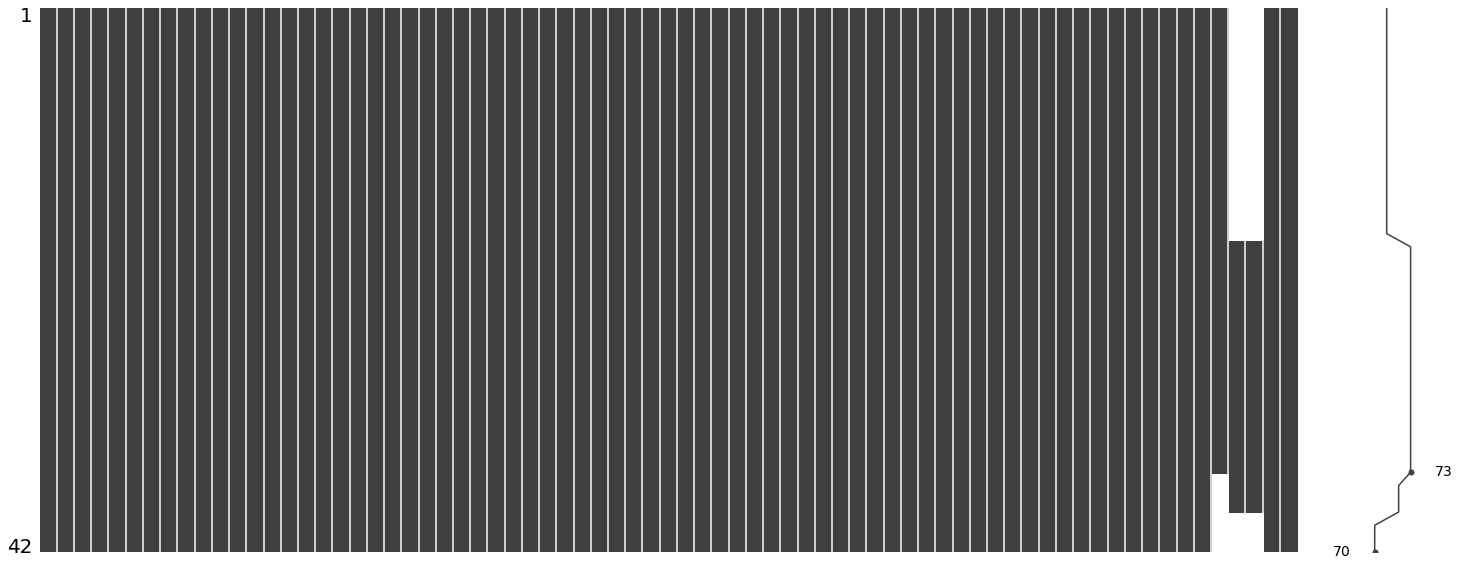

In [10]:
missingno.matrix(p1_df)

<AxesSubplot:>

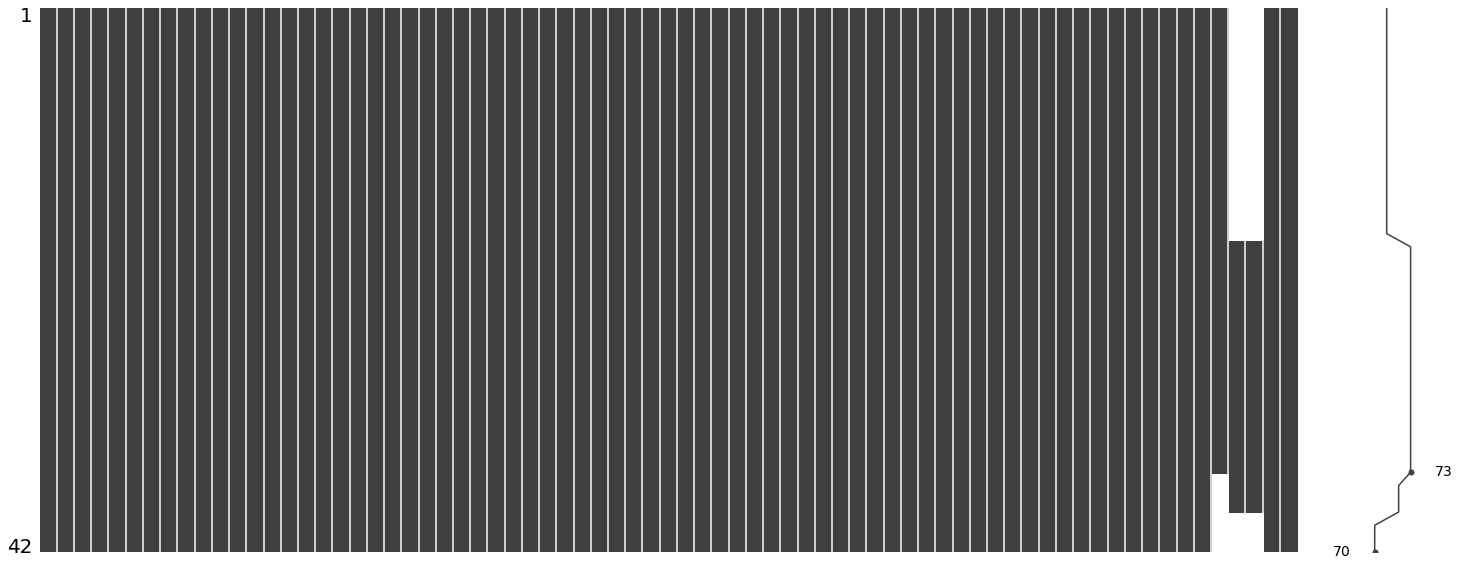

In [11]:
missingno.matrix(p2_df)

In [12]:
missing = describe_dataframe(p1_df, remove_zeros=True)
missing

,Column,Missing
0,mio_eur,14.2857
1,l_total,50.0000
2,unl_total,50.0000


In [13]:
missing = describe_dataframe(p2_df, remove_zeros=True)
missing

,Column,Missing
0,mio_eur,14.2857
1,l_total,50.0000
2,unl_total,50.0000


In [14]:
p1_df.cases_total.sum()

210

In [15]:
p2_df.cases_total.sum()

210

In [16]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'mio_eur']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['mio_eur']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [17]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'l_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['l_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [18]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'unl_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['unl_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

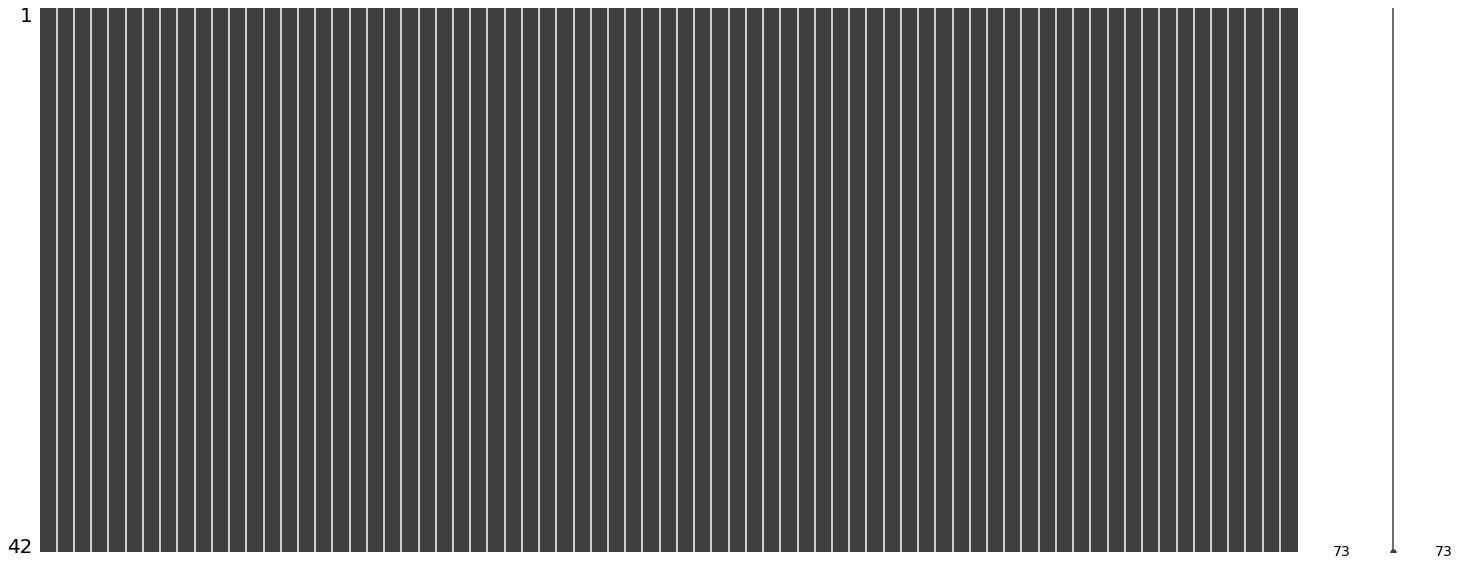

In [19]:
missingno.matrix(p1_df, label_rotation=90)

<AxesSubplot:>

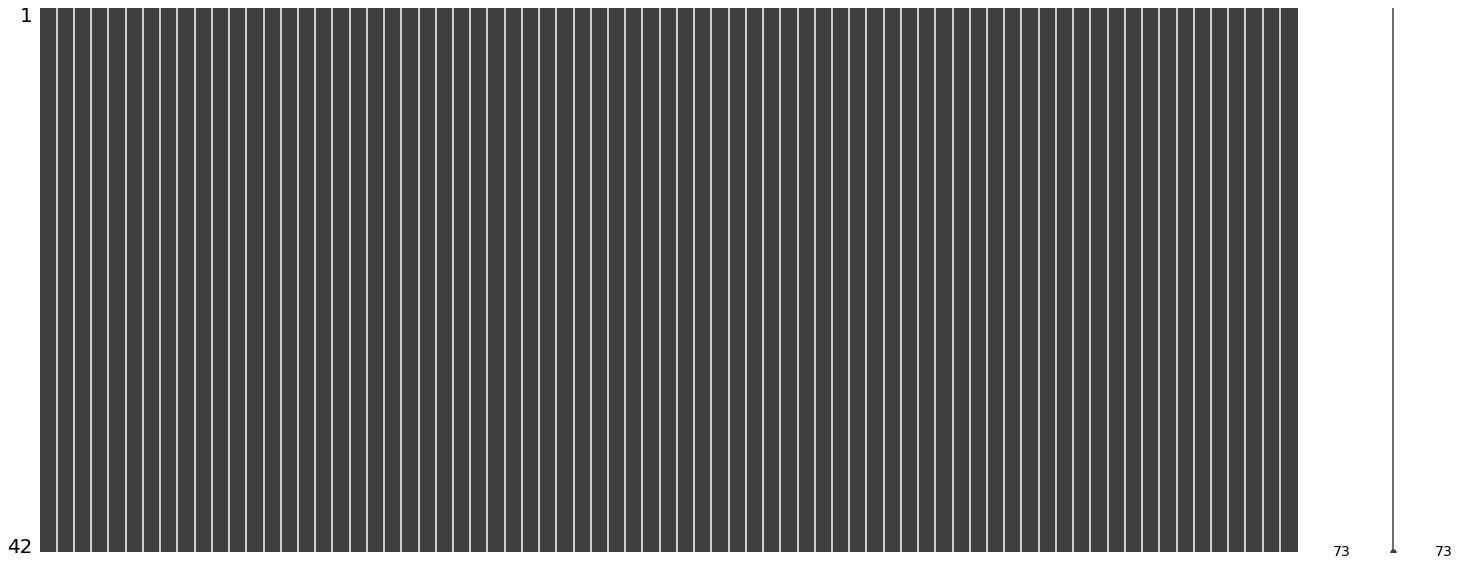

In [20]:
missingno.matrix(p2_df, label_rotation=90)

<AxesSubplot:>

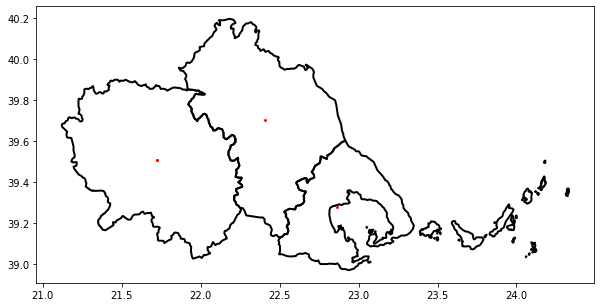

In [21]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(p1_df[['NUTS3_ID']], geometry=gpd.points_from_xy(p1_df.x, p1_df.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [22]:
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P1_2010_2023.csv", encoding = enc, index = False)
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P2_2010_2023.csv", encoding = enc, index = False)